# ML: prediccion de churn (cancelacion de suscripcion)

Stretch goal, fuera del stack obligatorio del README. Entrena un clasificador sobre `gold.fact_subscription` para predecir `is_cancelled`, y lo persiste para que la app de Streamlit lo consuma.

**Simplificacion declarada:** tratamos `is_cancelled` como una etiqueta binaria simple (cancelada vs. no-cancelada) en el momento de la corrida. En rigor esto es un problema de *censura* (una suscripcion `active` todavia puede cancelarse despues, no sabemos su destino final) -- para un modelo de negocio real convendria supervivencia (survival analysis) o una ventana de observacion fija. Para este ejercicio, la simplificacion es aceptable y estandar en modelos de churn introductorios.

## 1. Features -- y por que se excluyen otras

**Se usan:** `country`, `segment`, `is_student` (de `dim_customer`), `category`, `monthly_price` (de `dim_product`), `duration_days` (de `fact_subscription` -- es la duracion *contratada*, conocida desde el inicio de la suscripcion, no un resultado).

**Se excluyen a proposito:** `status` y `is_active` -- son el resultado observado, no una senal predictiva. `is_cancelled` se deriva de `status = 'cancelled'`, asi que usar `status` como feature seria filtracion de datos trivial (el modelo "predeciria" algo que ya sabe la respuesta).

In [1]:
import sys, os
sys.path.append("/home/jovyan/work/src")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

from utils.db import get_engine

engine = get_engine()
MODELS_ROOT = Path(os.environ.get("MODELS_ROOT", "/home/jovyan/work/models"))
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE = "#2a78d6", "#eb6834"

In [2]:
df = pd.read_sql("""
    SELECT s.is_cancelled,
           c.country, c.segment, c.is_student,
           p.category, p.monthly_price,
           s.duration_days
    FROM gold.fact_subscription s
    JOIN gold.dim_customer c ON c.customer_id = s.customer_id
    JOIN gold.dim_product p ON p.product_id = s.product_id
    WHERE s.duration_days IS NOT NULL
""", engine)

print("Filas:", len(df))
print("Balance de clases (is_cancelled):")
print(df["is_cancelled"].value_counts(normalize=True).round(3))

Filas: 14217
Balance de clases (is_cancelled):
is_cancelled
False    0.85
True     0.15
Name: proportion, dtype: float64


## 2. Split, pipeline y entrenamiento

`ColumnTransformer` con `OneHotEncoder` para categoricas y `StandardScaler` para numericas, dentro de un `Pipeline` con `RandomForestClassifier`. `class_weight="balanced"` porque `is_cancelled` es minoritaria (~15%).

In [3]:
CATEGORICAL = ["country", "segment", "category", "is_student"]
NUMERIC = ["monthly_price", "duration_days"]

X = df[CATEGORICAL + NUMERIC]
y = df["is_cancelled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)),
])

pipeline.fit(X_train, y_train)
print("Entrenado.")

Entrenado.


## 3. Evaluacion

              precision    recall  f1-score   support

  no_cancela       0.85      0.75      0.80      2416
     cancela       0.16      0.28      0.21       428

    accuracy                           0.68      2844
   macro avg       0.51      0.51      0.50      2844
weighted avg       0.75      0.68      0.71      2844

ROC-AUC: 0.513


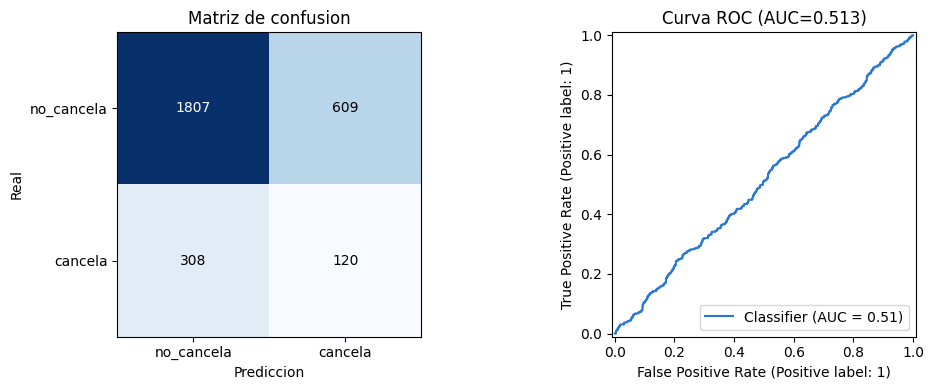

In [4]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["no_cancela", "cancela"]))
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["no_cancela", "cancela"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["no_cancela", "cancela"])
axes[0].set_xlabel("Prediccion"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de confusion")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=BLUE)
axes[1].set_title(f"Curva ROC (AUC={auc:.3f})")
plt.tight_layout()
plt.show()

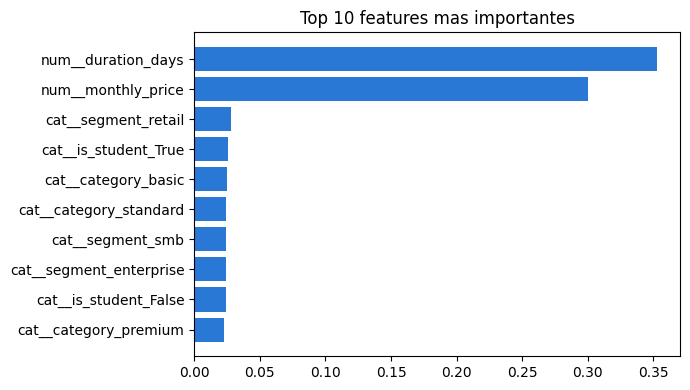

In [5]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_
imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp["feature"], imp["importance"], color=BLUE)
ax.set_title("Top 10 features mas importantes")
plt.tight_layout()
plt.show()

## 4. Persistir el modelo

Se guarda el pipeline completo (preprocesamiento + modelo) junto con las opciones validas de cada categorica y los rangos numericos -- asi la app de Streamlit arma el formulario sin necesitar conexion a la base de datos.

## 3.1 Hallazgo honesto: el modelo no supera el azar

**ROC-AUC ≈ 0.51** (0.50 = azar puro, 1.0 = perfecto). El grafico de importancia de features tampoco muestra ninguna variable dominante -- esta repartido de forma casi pareja, sesgado hacia las numericas (`duration_days`, `monthly_price`) por como Random Forest calcula importancia en variables continuas, no porque tengan senal real.

**Conclusion:** con las features disponibles, `is_cancelled` no es predecible mejor que adivinar al azar en este dataset. Es coherente con lo que ya vimos en `notebooks/analysis/01_insights.ipynb` -- el churn por segmento variaba solo 2 puntos (13.1%-15.2%), una diferencia demasiado chica para que un modelo la explote. La explicacion mas probable es que el generador sintetico de datos (`manifest.json`, `seed: 42`) asigno `status` de forma mayormente independiente de estos atributos -- no hay una relacion causal codificada en los datos para que el modelo aprenda.

No se fuerza el numero con mas *feature engineering* o *tuning* de hiperparametros: inflar el AUC sin una senal real seria sobreajustar al ruido, no mejorar el modelo. Se documenta el resultado tal cual salio -- el ejercicio demuestra el proceso completo (features, pipeline, evaluacion, persistencia) igual de bien con un resultado negativo que con uno positivo.

In [6]:
artifact = {
    "pipeline": pipeline,
    "categorical": CATEGORICAL,
    "numeric": NUMERIC,
    "feature_options": {col: sorted(df[col].dropna().unique().tolist(), key=str) for col in CATEGORICAL},
    "numeric_ranges": {col: (float(df[col].min()), float(df[col].max())) for col in NUMERIC},
    "metrics": {"roc_auc": float(auc)},
}

out_path = MODELS_ROOT / "churn_model.joblib"
joblib.dump(artifact, out_path)
print("Guardado en", out_path)

Guardado en /home/jovyan/work/models/churn_model.joblib
